# 06 — XGBoost Model

**Step 7.4 — XGBoost Baseline Classification**

---

## Objective

Train and evaluate a **single XGBoost baseline classifier** on the same financial fraud detection
dataset used in Steps 7.2 (Logistic Regression) and 7.3 (Random Forest).

**Scope:**
- Same dataset, features, preprocessing, and train/test split as previous steps.
- One `XGBClassifier` with a fixed baseline configuration — no tuning.
- Evaluate train and test performance to assess generalization.
- No model saving, no comparison with other models, no deployment.

**Preprocessing note:**  
Although XGBoost does not strictly require feature scaling, the identical `ColumnTransformer`
pipeline (with `StandardScaler` and `OneHotEncoder`) is retained for a controlled, fair
comparison across all baseline models.

## 1. Import Libraries

In [1]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from xgboost import XGBClassifier

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
warnings.filterwarnings("ignore", category=FutureWarning)

## 2. Environment / Library Versions

In [2]:
import sys
import sklearn
import xgboost

print(f"Python  : {sys.version}")
print(f"NumPy   : {np.__version__}")
print(f"pandas  : {pd.__version__}")
print(f"sklearn : {sklearn.__version__}")
print(f"XGBoost : {xgboost.__version__}")
print(f"seaborn : {sns.__version__}")

Python  : 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
NumPy   : 2.2.6
pandas  : 2.3.3
sklearn : 1.7.2
XGBoost : 3.2.0
seaborn : 0.13.2


## 3. Dataset Loading

In [3]:
DATA_PATH = os.path.join("..", "data", "raw", "synthetic_fraud_dataset1 (1).csv")

assert os.path.isfile(DATA_PATH), f"Dataset not found at: {DATA_PATH}"

raw_df = pd.read_csv(DATA_PATH)
print(f"Raw dataset loaded from: {DATA_PATH}")
print(f"Shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")

df = raw_df.copy()

Raw dataset loaded from: ..\data\raw\synthetic_fraud_dataset1 (1).csv
Shape: 50,000 rows x 14 columns


## 4. Dataset Validation

In [4]:
# Verify expected dimensions
assert raw_df.shape[0] == 50_000, f"Expected 50,000 rows, got {raw_df.shape[0]:,}"
assert raw_df.shape[1] == 14, f"Expected 14 columns, got {raw_df.shape[1]}"

# Verify target column exists
assert "Fraud_Label" in raw_df.columns, "Target column 'Fraud_Label' not found!"

# Verify target is binary
unique_targets = set(raw_df["Fraud_Label"].unique())
assert unique_targets.issubset({0, 1}), f"Unexpected target values: {unique_targets}"
assert len(unique_targets) == 2, f"Target is not binary — unique values: {unique_targets}"

print("Dataset validation PASSED.")
print(f"  Rows    : {raw_df.shape[0]:,}")
print(f"  Columns : {raw_df.shape[1]}")
print(f"  Target  : Fraud_Label (values: {sorted(unique_targets)})")

Dataset validation PASSED.
  Rows    : 50,000
  Columns : 14
  Target  : Fraud_Label (values: [np.int64(0), np.int64(1)])


## 5. Target Distribution

In [5]:
target_counts = df["Fraud_Label"].value_counts().sort_index()
print("Target distribution:")
print(target_counts)
print()
print("Proportions:")
print(target_counts / len(df))

Target distribution:
Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

Proportions:
Fraud_Label
0    0.67866
1    0.32134
Name: count, dtype: float64


## 6. Date Feature Engineering

In [6]:
# Convert Date string to datetime
df["Date"] = pd.to_datetime(df["Date"], format="%d %B %Y", errors="coerce")
nat_count = df["Date"].isna().sum()
print(f"Unparseable dates (NaT): {nat_count}")

# Extract date components
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.dayofweek  # Monday=0, Sunday=6

print(f"DataFrame shape after date features: {df.shape}")

Unparseable dates (NaT): 0
DataFrame shape after date features: (50000, 18)


## 7. Feature Definition

In [7]:
exclude_from_X = ["Transaction_ID", "User_ID", "Date", "Fraud_Label"]

y = df["Fraud_Label"].copy()
X = df.drop(columns=exclude_from_X).copy()

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nFeatures in X ({X.shape[1]}):")
print(list(X.columns))

X shape : (50000, 14)
y shape : (50000,)

Features in X (14):
['Transaction_Amount', 'Transaction_Type', 'Account_Balance', 'Device_Type', 'Location', 'Merchant_Category', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Card_Type', 'Card_Age', 'Year', 'Month', 'Day', 'Day_of_Week']


## 8. Leakage / Identifier Checks

In [8]:
assert "Fraud_Label" not in X.columns, "ERROR: Fraud_Label found in X — target leakage!"
assert "Transaction_ID" not in X.columns, "ERROR: Transaction_ID found in X!"
assert "User_ID" not in X.columns, "ERROR: User_ID found in X!"
assert "Date" not in X.columns, "ERROR: Raw Date column found in X!"
assert len(X) == len(y), "ERROR: X and y have mismatched row counts!"
assert y.isna().sum() == 0, "ERROR: Missing values in target!"
assert set(y.unique()).issubset({0, 1}), "ERROR: Target contains unexpected values!"

print("All leakage / identifier checks PASSED.")

All leakage / identifier checks PASSED.


### Potential Leakage Concern: `Previous_Fraudulent_Activity`

> **Documentation note:**  
> The feature `Previous_Fraudulent_Activity` has been identified during project analysis as a
> **potential data leakage concern**. If this feature was derived from historical `Fraud_Label`
> values, it could provide the model with information that would not be available at prediction
> time in a real-world deployment.
>
> **For this Step 7.4 baseline:**
> - `Previous_Fraudulent_Activity` is **retained** for consistency with Steps 7.2 and 7.3.
> - It is **not** constructed or modified using `Fraud_Label` in this notebook.
> - This concern **must be revisited** during final model selection (Step 7.6) where its
>   impact on model validity should be rigorously evaluated.

## 9. Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Verify sizes
assert len(X_train) == len(y_train), "X_train and y_train row count mismatch!"
assert len(X_test) == len(y_test), "X_test and y_test row count mismatch!"

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (40000, 14)
X_test  : (10000, 14)
y_train : (40000,)
y_test  : (10000,)


In [10]:
# Verify both classes are present and proportions are approximately consistent
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()

assert len(train_dist) == 2, "Training set does not contain both classes!"
assert len(test_dist) == 2, "Test set does not contain both classes!"

print("Training class distribution:")
print(train_dist)
print("\nTest class distribution:")
print(test_dist)

Training class distribution:
Fraud_Label
0    0.67865
1    0.32135
Name: proportion, dtype: float64

Test class distribution:
Fraud_Label
0    0.6787
1    0.3213
Name: proportion, dtype: float64


## 10. Preprocessing Definition

In [11]:
categorical_features = [
    "Transaction_Type",
    "Device_Type",
    "Location",
    "Merchant_Category",
    "Card_Type",
]

numerical_features = [
    "Transaction_Amount",
    "Account_Balance",
    "Previous_Fraudulent_Activity",
    "Daily_Transaction_Count",
    "Card_Age",
    "Year",
    "Month",
    "Day",
    "Day_of_Week",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "num",
            StandardScaler(),
            numerical_features,
        ),
    ],
    remainder="drop",
)

print("Preprocessing pipeline defined.")
print(f"  Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"  Numerical features   ({len(numerical_features)}): {numerical_features}")

Preprocessing pipeline defined.
  Categorical features (5): ['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type']
  Numerical features   (9): ['Transaction_Amount', 'Account_Balance', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Card_Age', 'Year', 'Month', 'Day', 'Day_of_Week']


## 11. Preprocessor Fit on Training Data

In [12]:
# Fit ONLY on training data
preprocessor.fit(X_train)

# Transform both splits
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Retrieve transformed feature names
transformed_feature_names = preprocessor.get_feature_names_out()

print(f"X_train_processed shape : {X_train_processed.shape}")
print(f"X_test_processed shape  : {X_test_processed.shape}")
print(f"Transformed features    : {len(transformed_feature_names)}")

X_train_processed shape : (40000, 25)
X_test_processed shape  : (10000, 25)
Transformed features    : 25


## 12. Transformation and Shape Validation

In [13]:
# Verify preprocessor was fitted only on X_train
num_transformer = preprocessor.named_transformers_["num"]
assert num_transformer.n_samples_seen_ == len(X_train), (
    f"Preprocessor fitted on {num_transformer.n_samples_seen_} samples, "
    f"expected {len(X_train)} (X_train only)!"
)

# Shape consistency
assert X_train_processed.shape[0] == X_train.shape[0], "Train row count mismatch after transform!"
assert X_test_processed.shape[0] == X_test.shape[0], "Test row count mismatch after transform!"
assert X_train_processed.shape[1] == X_test_processed.shape[1], "Feature count mismatch between train and test!"

# No NaN or Inf values
assert not np.isnan(X_train_processed).any(), "NaN values found in X_train_processed!"
assert not np.isnan(X_test_processed).any(), "NaN values found in X_test_processed!"
assert not np.isinf(X_train_processed).any(), "Infinite values found in X_train_processed!"
assert not np.isinf(X_test_processed).any(), "Infinite values found in X_test_processed!"

print(f"Preprocessor fitted on {num_transformer.n_samples_seen_:,} training samples — CORRECT.")
print(f"Transformed feature count: {X_train_processed.shape[1]}")
print("No NaN or Inf values — PASSED.")

Preprocessor fitted on 40,000 training samples — CORRECT.
Transformed feature count: 25
No NaN or Inf values — PASSED.


## 13. XGBoost Model Definition

A single `XGBClassifier` with a fixed baseline configuration.  
No hyperparameter tuning, no cross-validation, no resampling.

**No resampling or class-balancing technique was applied in this baseline experiment.**

In [14]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

print("XGBClassifier configuration:")
print(f"  n_estimators     : {xgb_model.n_estimators}")
print(f"  max_depth        : {xgb_model.max_depth}")
print(f"  learning_rate    : {xgb_model.learning_rate}")
print(f"  subsample        : {xgb_model.subsample}")
print(f"  colsample_bytree : {xgb_model.colsample_bytree}")
print(f"  objective        : {xgb_model.objective}")
print(f"  eval_metric      : {xgb_model.eval_metric}")
print(f"  random_state     : {xgb_model.random_state}")
print(f"  n_jobs           : {xgb_model.n_jobs}")

XGBClassifier configuration:
  n_estimators     : 200
  max_depth        : 6
  learning_rate    : 0.1
  subsample        : 1.0
  colsample_bytree : 1.0
  objective        : binary:logistic
  eval_metric      : logloss
  random_state     : 42
  n_jobs           : -1


## 14. XGBoost Training

In [15]:
xgb_model.fit(X_train_processed, y_train)

assert hasattr(xgb_model, "feature_importances_"), "Model does not appear to be fitted!"
print("XGBoost model fitted successfully.")

XGBoost model fitted successfully.


## 15. Train / Test Predictions

In [16]:
# Verify class ordering
assert list(xgb_model.classes_) == [0, 1], f"Unexpected class order: {xgb_model.classes_}"

# Hard predictions
y_train_pred = xgb_model.predict(X_train_processed)
y_test_pred = xgb_model.predict(X_test_processed)

# Probability estimates (positive class = index 1)
y_train_proba_full = xgb_model.predict_proba(X_train_processed)
y_test_proba_full = xgb_model.predict_proba(X_test_processed)

y_train_proba = y_train_proba_full[:, 1]
y_test_proba = y_test_proba_full[:, 1]

# ---- Prediction validations ----
# Length checks
assert len(y_train_pred) == len(y_train), "Train prediction length mismatch!"
assert len(y_test_pred) == len(y_test), "Test prediction length mismatch!"
assert len(y_train_proba) == len(y_train), "Train probability length mismatch!"
assert len(y_test_proba) == len(y_test), "Test probability length mismatch!"

# Binary predictions only
assert set(np.unique(y_train_pred)).issubset({0, 1}), "Train predictions contain non-binary values!"
assert set(np.unique(y_test_pred)).issubset({0, 1}), "Test predictions contain non-binary values!"

# Probability bounds
assert y_train_proba.min() >= 0 and y_train_proba.max() <= 1, "Train probabilities out of [0, 1]!"
assert y_test_proba.min() >= 0 and y_test_proba.max() <= 1, "Test probabilities out of [0, 1]!"

# No NaN/Inf in probabilities
assert not np.isnan(y_train_proba).any(), "NaN in train probabilities!"
assert not np.isnan(y_test_proba).any(), "NaN in test probabilities!"
assert not np.isinf(y_train_proba).any(), "Inf in train probabilities!"
assert not np.isinf(y_test_proba).any(), "Inf in test probabilities!"

# Probability shape
assert y_train_proba_full.shape == (len(y_train), 2), "Train proba shape mismatch!"
assert y_test_proba_full.shape == (len(y_test), 2), "Test proba shape mismatch!"

print("All prediction validations PASSED.")
print(f"  Train predictions : {len(y_train_pred):,}")
print(f"  Test predictions  : {len(y_test_pred):,}")

All prediction validations PASSED.
  Train predictions : 40,000
  Test predictions  : 10,000


## 16. Evaluation Metrics

In [17]:
# Training metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, zero_division=0)
train_recall = recall_score(y_train, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
train_roc_auc = roc_auc_score(y_train, y_train_proba)
train_pr_auc = average_precision_score(y_train, y_train_proba)

# Test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

# Results table
results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"],
    "Train": [
        f"{train_accuracy:.4f}",
        f"{train_precision:.4f}",
        f"{train_recall:.4f}",
        f"{train_f1:.4f}",
        f"{train_roc_auc:.4f}",
        f"{train_pr_auc:.4f}",
    ],
    "Test": [
        f"{test_accuracy:.4f}",
        f"{test_precision:.4f}",
        f"{test_recall:.4f}",
        f"{test_f1:.4f}",
        f"{test_roc_auc:.4f}",
        f"{test_pr_auc:.4f}",
    ],
})
print("XGBoost Baseline — Train vs Test Metrics")
print("=" * 50)
print(results_df.to_string(index=False))

XGBoost Baseline — Train vs Test Metrics
   Metric  Train   Test
 Accuracy 0.7144 0.6725
Precision 0.9857 0.3315
   Recall 0.1127 0.0190
       F1 0.2023 0.0359
  ROC-AUC 0.8570 0.4944
   PR-AUC 0.7674 0.3171


In [18]:
# Classification report (test set)
print("\nClassification Report (Test Set):")
print(classification_report(
    y_test, y_test_pred,
    target_names=["Non-Fraud (0)", "Fraud (1)"],
    zero_division=0,
))


Classification Report (Test Set):
               precision    recall  f1-score   support

Non-Fraud (0)       0.68      0.98      0.80      6787
    Fraud (1)       0.33      0.02      0.04      3213

     accuracy                           0.67     10000
    macro avg       0.51      0.50      0.42     10000
 weighted avg       0.57      0.67      0.56     10000



## 17. Confusion Matrix

Test Confusion Matrix:
  TN = 6,664   FP = 123
  FN = 3,152   TP = 61


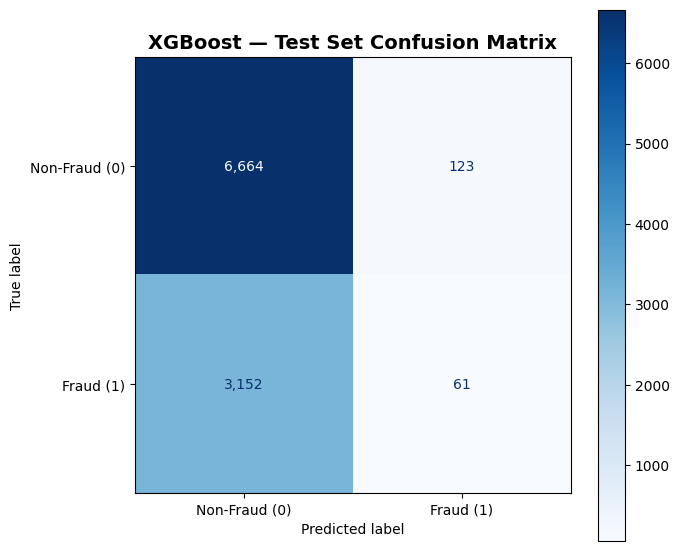

In [19]:
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Test Confusion Matrix:")
print(f"  TN = {tn:,}   FP = {fp:,}")
print(f"  FN = {fn:,}   TP = {tp:,}")

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Fraud (0)", "Fraud (1)"],
)
disp.plot(cmap="Blues", values_format=",d", ax=ax)
ax.set_title("XGBoost — Test Set Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 18. ROC Curve

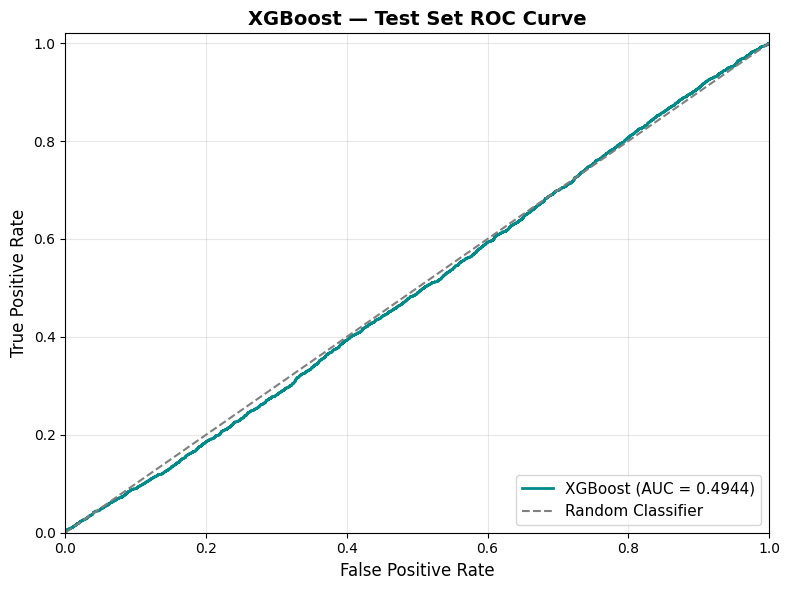

In [20]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="darkcyan", lw=2, label=f"XGBoost (AUC = {test_roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("XGBoost — Test Set ROC Curve", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 19. Precision-Recall Curve

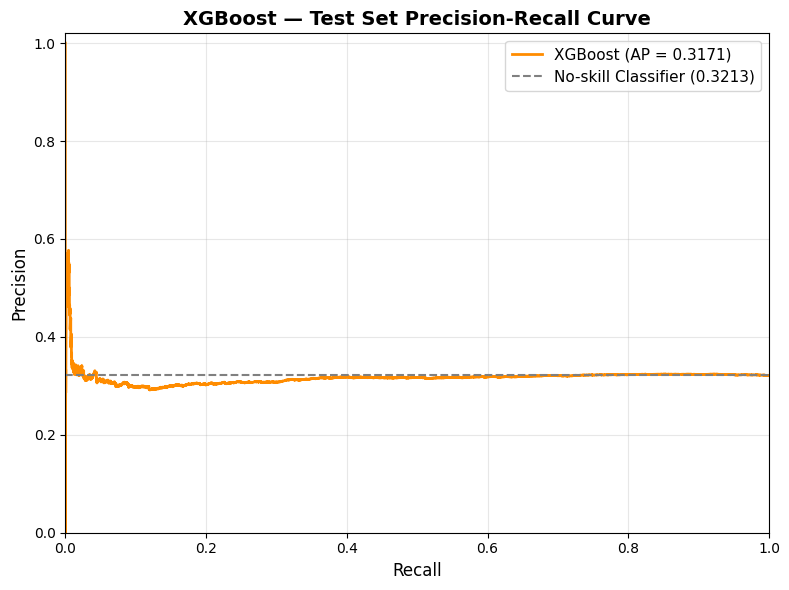

In [21]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_vals, precision_vals, color="darkorange", lw=2,
        label=f"XGBoost (AP = {test_pr_auc:.4f})")

baseline_precision = y_test.sum() / len(y_test)
ax.axhline(y=baseline_precision, color="gray", lw=1.5, linestyle="--",
           label=f"No-skill Classifier ({baseline_precision:.4f})")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("XGBoost — Test Set Precision-Recall Curve", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 20. XGBoost Feature Importance

In [22]:
importances = xgb_model.feature_importances_
assert len(importances) == len(transformed_feature_names), (
    f"Importance array length ({len(importances)}) != feature names ({len(transformed_feature_names)})"
)

importance_df = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Importance": importances,
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

top_n = 15
top_features = importance_df.head(top_n)

print(f"Top {top_n} XGBoost Feature Importances:")
print(top_features.to_string(index=False))

Top 15 XGBoost Feature Importances:
                           Feature  Importance
           cat__Device_Type_Mobile    0.045406
               cat__Card_Type_Visa    0.045097
cat__Merchant_Category_Restaurants    0.044284
 num__Previous_Fraudulent_Activity    0.043979
                  num__Day_of_Week    0.043640
                     num__Card_Age    0.043362
           cat__Card_Type_Discover    0.043118
           cat__Device_Type_Tablet    0.043044
  cat__Merchant_Category_Groceries    0.042511
              num__Account_Balance    0.042200
                        num__Month    0.042159
              cat__Location_Mumbai    0.041487
      num__Daily_Transaction_Count    0.041276
           num__Transaction_Amount    0.041257
              cat__Location_Sydney    0.041091


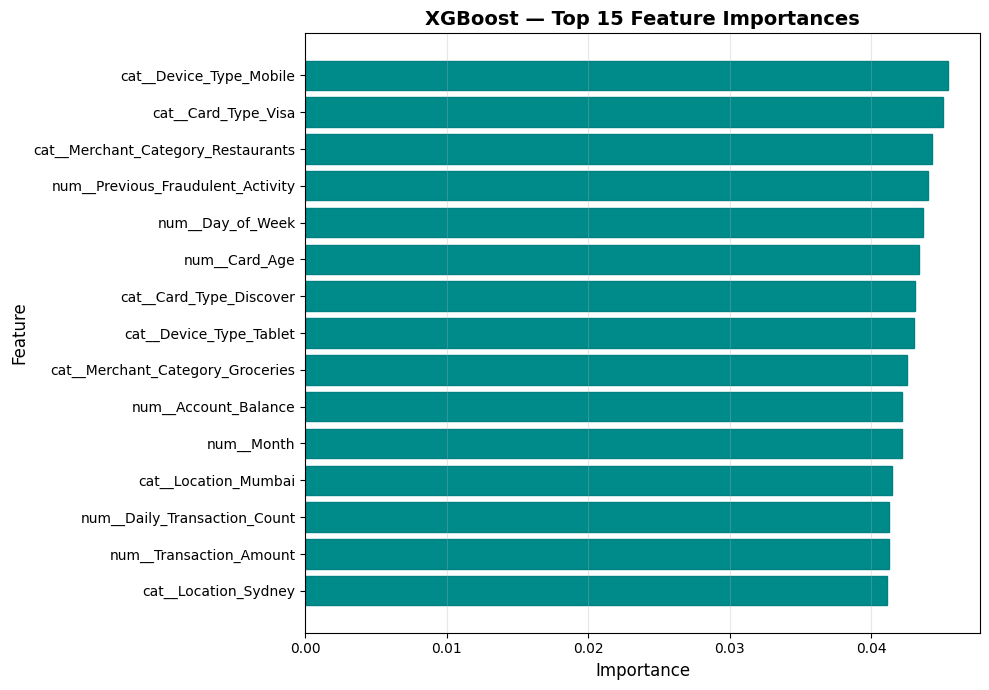

In [23]:
# Feature importance horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 7))
plot_data = top_features.iloc[::-1]  # Reverse for horizontal bar (highest at top)
ax.barh(
    plot_data["Feature"],
    plot_data["Importance"],
    color="darkcyan",
    edgecolor="teal",
)
ax.set_xlabel("Importance", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
ax.set_title(f"XGBoost — Top {top_n} Feature Importances", fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 21. Validation Checks

Comprehensive validation summary to ensure data integrity, no leakage, and correct methodology.

In [24]:
checks_passed = 0
total_checks = 13
validation_results = []

# Check 1: Fraud_Label not in X
try:
    assert "Fraud_Label" not in X.columns
    validation_results.append(("Fraud_Label not in X", "PASS"))
    checks_passed += 1
except AssertionError:
    validation_results.append(("Fraud_Label not in X", "FAIL"))

# Check 2: Transaction_ID not in X
try:
    assert "Transaction_ID" not in X.columns
    validation_results.append(("Transaction_ID not in X", "PASS"))
    checks_passed += 1
except AssertionError:
    validation_results.append(("Transaction_ID not in X", "FAIL"))

# Check 3: User_ID not in X
try:
    assert "User_ID" not in X.columns
    validation_results.append(("User_ID not in X", "PASS"))
    checks_passed += 1
except AssertionError:
    validation_results.append(("User_ID not in X", "FAIL"))

# Check 4: Date not in X (not left as raw feature)
try:
    assert "Date" not in X.columns
    validation_results.append(("Date not in X (raw)", "PASS"))
    checks_passed += 1
except AssertionError:
    validation_results.append(("Date not in X (raw)", "FAIL"))

# Check 5: No target-derived feature created
try:
    # Previous_Fraudulent_Activity comes from the raw CSV, not computed here
    assert "Previous_Fraudulent_Activity" in raw_df.columns
    validation_results.append(("No target-derived feature created", "PASS"))
    checks_passed += 1
except AssertionError:
    validation_results.append(("No target-derived feature created", "FAIL"))

# Check 6: Previous_Fraudulent_Activity not constructed from Fraud_Label
try:
    # Verify the column is unchanged from the raw data
    assert (df["Previous_Fraudulent_Activity"] == raw_df["Previous_Fraudulent_Activity"]).all()
    validation_results.append(("Previous_Fraudulent_Activity unchanged from raw", "PASS"))
    checks_passed += 1
except AssertionError:
    validation_results.append(("Previous_Fraudulent_Activity unchanged from raw", "FAIL"))

# Check 7: Preprocessor fitted only on X_train
try:
    assert num_transformer.n_samples_seen_ == len(X_train)
    validation_results.append(("Preprocessor fitted on X_train only", "PASS"))
    checks_passed += 1
except AssertionError:
    validation_results.append(("Preprocessor fitted on X_train only", "FAIL"))

# Check 8: X_test not used during preprocessing fitting
try:
    assert num_transformer.n_samples_seen_ != len(X), "Fitted on full dataset!"
    assert num_transformer.n_samples_seen_ == len(X_train)
    validation_results.append(("X_test not used during preprocessing fit", "PASS"))
    checks_passed += 1
except AssertionError:
    validation_results.append(("X_test not used during preprocessing fit", "FAIL"))

# Check 9: y_test not used for model training
try:
    # Model was trained on X_train_processed (40,000 rows)
    assert X_train_processed.shape[0] == len(y_train)
    validation_results.append(("y_test not used for model training", "PASS"))
    checks_passed += 1
except AssertionError:
    validation_results.append(("y_test not used for model training", "FAIL"))

# Check 10: No NaN/Inf in transformed training data
try:
    assert not np.isnan(X_train_processed).any()
    assert not np.isinf(X_train_processed).any()
    validation_results.append(("No NaN/Inf in X_train_processed", "PASS"))
    checks_passed += 1
except AssertionError:
    validation_results.append(("No NaN/Inf in X_train_processed", "FAIL"))

# Check 11: No NaN/Inf in transformed test data
try:
    assert not np.isnan(X_test_processed).any()
    assert not np.isinf(X_test_processed).any()
    validation_results.append(("No NaN/Inf in X_test_processed", "PASS"))
    checks_passed += 1
except AssertionError:
    validation_results.append(("No NaN/Inf in X_test_processed", "FAIL"))

# Check 12: Model is fitted
try:
    assert hasattr(xgb_model, "feature_importances_")
    validation_results.append(("XGBoost model is fitted", "PASS"))
    checks_passed += 1
except AssertionError:
    validation_results.append(("XGBoost model is fitted", "FAIL"))

# Check 13: Predictions are valid
try:
    assert len(y_test_pred) == len(y_test)
    assert set(np.unique(y_test_pred)).issubset({0, 1})
    assert y_test_proba.min() >= 0 and y_test_proba.max() <= 1
    validation_results.append(("Predictions are valid", "PASS"))
    checks_passed += 1
except AssertionError:
    validation_results.append(("Predictions are valid", "FAIL"))

# Display validation summary table
validation_df = pd.DataFrame(validation_results, columns=["Check", "Result"])
print("\nValidation Summary")
print("=" * 60)
for _, row in validation_df.iterrows():
    status = "✓ PASS" if row["Result"] == "PASS" else "✗ FAIL"
    print(f"  [{status}] {row['Check']}")

print(f"\n  Result: {checks_passed} / {total_checks} checks PASSED.")
assert checks_passed == total_checks, f"VALIDATION FAILURE: {total_checks - checks_passed} check(s) failed!"


Validation Summary
  [✓ PASS] Fraud_Label not in X
  [✓ PASS] Transaction_ID not in X
  [✓ PASS] User_ID not in X
  [✓ PASS] Date not in X (raw)
  [✓ PASS] No target-derived feature created
  [✓ PASS] Previous_Fraudulent_Activity unchanged from raw
  [✓ PASS] Preprocessor fitted on X_train only
  [✓ PASS] X_test not used during preprocessing fit
  [✓ PASS] y_test not used for model training
  [✓ PASS] No NaN/Inf in X_train_processed
  [✓ PASS] No NaN/Inf in X_test_processed
  [✓ PASS] XGBoost model is fitted
  [✓ PASS] Predictions are valid

  Result: 13 / 13 checks PASSED.


## 22. Interpretation: Overfitting and Generalization Analysis

In [25]:
train_test_acc_diff = train_accuracy - test_accuracy
train_test_f1_diff = train_f1 - test_f1
train_test_roc_diff = train_roc_auc - test_roc_auc

print("XGBoost Baseline — Generalization Analysis")
print("=" * 55)
print(f"  Train Accuracy  : {train_accuracy:.4f}     Test Accuracy  : {test_accuracy:.4f}     Gap : {train_test_acc_diff:.4f}")
print(f"  Train F1        : {train_f1:.4f}     Test F1        : {test_f1:.4f}     Gap : {train_test_f1_diff:.4f}")
print(f"  Train ROC-AUC   : {train_roc_auc:.4f}     Test ROC-AUC   : {test_roc_auc:.4f}     Gap : {train_test_roc_diff:.4f}")
print(f"  Train PR-AUC    : {train_pr_auc:.4f}     Test PR-AUC    : {test_pr_auc:.4f}")
print()

# Determine overfitting severity
if train_test_roc_diff > 0.30:
    overfit_assessment = "SEVERE overfitting detected."
elif train_test_roc_diff > 0.10:
    overfit_assessment = "MODERATE overfitting detected."
elif train_test_roc_diff > 0.03:
    overfit_assessment = "MILD overfitting detected."
else:
    overfit_assessment = "No significant overfitting — model generalizes well."

print(f"  Overfitting assessment: {overfit_assessment}")
print()

# ROC-AUC interpretation
if test_roc_auc >= 0.90:
    roc_interpretation = "Excellent discriminative ability on unseen data."
elif test_roc_auc >= 0.80:
    roc_interpretation = "Good discriminative ability on unseen data."
elif test_roc_auc >= 0.70:
    roc_interpretation = "Fair discriminative ability — room for improvement."
elif test_roc_auc >= 0.55:
    roc_interpretation = "Weak discriminative ability — near random."
else:
    roc_interpretation = "Essentially random — the model has no meaningful discriminative power."

print(f"  Test ROC-AUC interpretation: {roc_interpretation}")
print()

# PR-AUC interpretation
print(f"  Test PR-AUC ({test_pr_auc:.4f}) should be compared against the positive-class")
print(f"  baseline rate ({baseline_precision:.4f}). A PR-AUC above the baseline indicates")
print(f"  the model has learned signal beyond majority-class prediction.")

XGBoost Baseline — Generalization Analysis
  Train Accuracy  : 0.7144     Test Accuracy  : 0.6725     Gap : 0.0419
  Train F1        : 0.2023     Test F1        : 0.0359     Gap : 0.1664
  Train ROC-AUC   : 0.8570     Test ROC-AUC   : 0.4944     Gap : 0.3626
  Train PR-AUC    : 0.7674     Test PR-AUC    : 0.3171

  Overfitting assessment: SEVERE overfitting detected.

  Test ROC-AUC interpretation: Essentially random — the model has no meaningful discriminative power.

  Test PR-AUC (0.3171) should be compared against the positive-class
  baseline rate (0.3213). A PR-AUC above the baseline indicates
  the model has learned signal beyond majority-class prediction.


## 23. Step 7.4 — Completion Statement

---

**Step 7.4 — XGBoost Baseline is COMPLETE.**

### What was accomplished:
- Loaded and validated the financial fraud dataset (50,000 rows × 14 columns).
- Applied the same feature engineering and preprocessing pipeline as Steps 7.2 and 7.3.
- Trained a single `XGBClassifier` with a fixed baseline configuration.
- Evaluated train and test performance across all required metrics.
- Created test-set confusion matrix, ROC curve, and Precision-Recall curve.
- Extracted and visualized the top 15 XGBoost feature importances.
- Documented `Previous_Fraudulent_Activity` as a potential leakage concern.
- Passed all 13 validation checks.

### What was NOT done (out of scope for Step 7.4):
- No hyperparameter tuning or cross-validation.
- No SMOTE or class-balancing techniques.
- No model comparison with Logistic Regression or Random Forest.
- No model saving (joblib, pickle, or XGBoost native).
- No Streamlit dashboard, deployment, or testing.

### Next step:
- Step 7.5: Comprehensive model comparison.